In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv('C:\\Users\\Acer\\Desktop\\IPL_Project\\Data\\deliveries_updated_ipl_upto_2025.csv', index_col=0)

In [5]:
df.select_dtypes(include=object)

,batting_team,bowling_team,batsman,non_striker,bowler,dismissal_kind,player_dismissed,date
matchId,,,,,,,,
335982,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,NaN,NaN,2008-04-18
335982,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,NaN,NaN,2008-04-18
335982,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,NaN,NaN,2008-04-18
335982,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,NaN,NaN,2008-04-18
335982,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,NaN,NaN,2008-04-18
...,...,...,...,...,...,...,...,...
1473511,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,JR Hazlewood,NaN,NaN,2025-06-03
1473511,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,JR Hazlewood,NaN,NaN,2025-06-03
1473511,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,JR Hazlewood,NaN,NaN,2025-06-03


In [6]:
df['batsman'].nunique()

704

In [7]:
sorted(df['batsman'].unique())

['A Ashish Reddy',
 'A Badoni',
 'A Chandila',
 'A Chopra',
 'A Choudhary',
 'A Dananjaya',
 'A Flintoff',
 'A Kamboj',
 'A Kumble',
 'A Manohar',
 'A Mhatre',
 'A Mishra',
 'A Mithun',
 'A Mukund',
 'A Nehra',
 'A Nortje',
 'A Raghuvanshi',
 'A Singh',
 'A Symonds',
 'A Tomar',
 'A Uniyal',
 'A Zampa',
 'AA Bilakhia',
 'AA Chavan',
 'AA Jhunjhunwala',
 'AA Kulkarni',
 'AA Noffke',
 'AB Agarkar',
 'AB Barath',
 'AB Dinda',
 'AB McDonald',
 'AB de Villiers',
 'AC Blizzard',
 'AC Gilchrist',
 'AC Thomas',
 'AC Voges',
 'AD Hales',
 'AD Mascarenhas',
 'AD Mathews',
 'AD Nath',
 'AD Russell',
 'AF Milne',
 'AG Murtaza',
 'AG Paunikar',
 'AJ Finch',
 'AJ Hosein',
 'AJ Turner',
 'AJ Tye',
 'AK Markram',
 'AL Menaria',
 'AM Nayar',
 'AM Rahane',
 'AN Ahmed',
 'AN Ghosh',
 'AP Dole',
 'AP Majumdar',
 'AP Tare',
 'AR Bawne',
 'AR Patel',
 'AS Joseph',
 'AS Rajpoot',
 'AS Raut',
 'AS Roy',
 'AS Yadav',
 'AT Carey',
 'AT Rayudu',
 'AU Rashid',
 'AUK Pathan',
 'Abdul Basith',
 'Abdul Samad',
 'Abd

In [8]:
df['batsman'].str.strip()

matchId
335982         SC Ganguly
335982        BB McCullum
335982        BB McCullum
335982        BB McCullum
335982        BB McCullum
                ...      
1473511    Shashank Singh
1473511    Shashank Singh
1473511    Shashank Singh
1473511    Shashank Singh
1473511    Shashank Singh
Name: batsman, Length: 278205, dtype: str

In [9]:
df['year']=pd.to_datetime(df['date']).dt.year

In [10]:
df['is_six']= (df['batsman_runs']== 6).astype(int)

In [11]:
Batter_Yearly_Runs = df.groupby(['year','batsman'])['batsman_runs'].sum().reset_index()
Batter_Yearly_Runs

,year,batsman,batsman_runs
0,2008,A Chopra,42
1,2008,A Kumble,13
2,2008,A Mishra,37
3,2008,A Mukund,0
4,2008,A Nehra,3
...,...,...,...
2778,2025,WG Jacks,233
2779,2025,Washington Sundar,133
2780,2025,XC Bartlett,11
2781,2025,YBK Jaiswal,559


In [12]:
Orange_Cap_Winners = Batter_Yearly_Runs.groupby('year')['batsman_runs'].idxmax()
Orange_Cap_Winners = Batter_Yearly_Runs.loc[Orange_Cap_Winners]
Orange_Cap_Winners

,year,batsman,batsman_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641


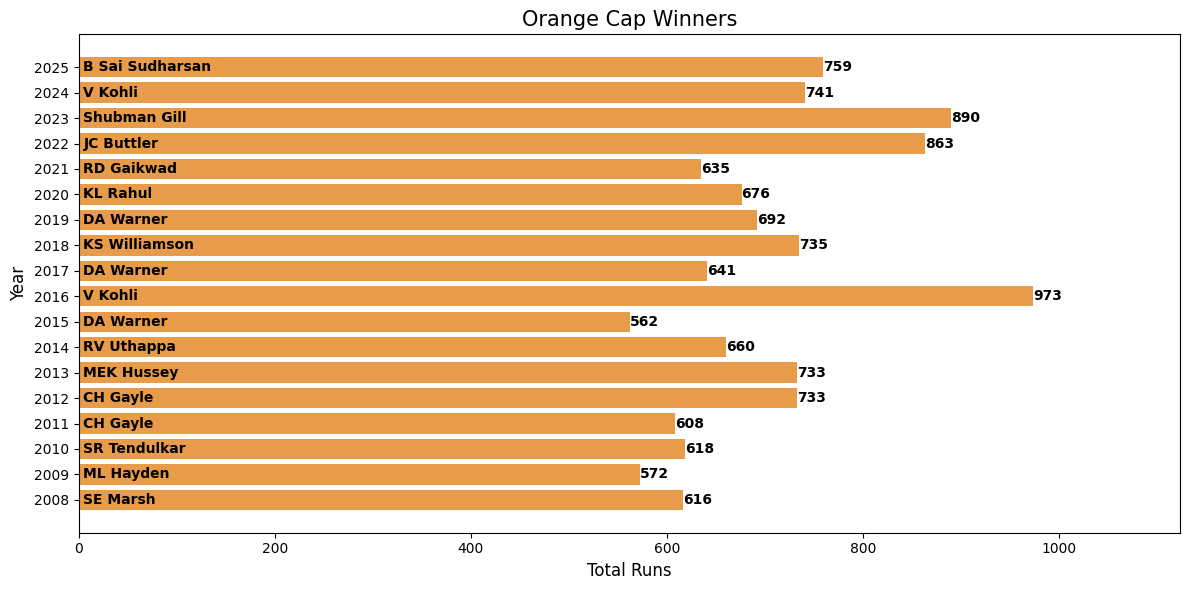

In [22]:
plt.figure(figsize=(12,6))
plt.barh(Orange_Cap_Winners['year'].astype(str),Orange_Cap_Winners['batsman_runs'], color="#e89b48")
plt.xlabel('Total Runs', fontsize=12)
plt.ylabel('Year', fontsize=12)
for i, (batsman, batsman_runs, year) in enumerate(zip(Orange_Cap_Winners['batsman'],
                                                      Orange_Cap_Winners['batsman_runs'],
                                                      Orange_Cap_Winners['year'])):
  plt.text(5, i, batsman, ha='left', va='center', fontweight='bold')

for i, (batsman, batsman_runs, year) in enumerate(zip(Orange_Cap_Winners['batsman'],
                                                      Orange_Cap_Winners['batsman_runs'],
                                                      Orange_Cap_Winners['year'])):
  plt.text(batsman_runs, i, batsman_runs, ha='left', va="center", fontweight='bold')

plt.title('Orange Cap Winners', fontsize=15)
plt.xlim(0, Orange_Cap_Winners['batsman_runs'].max() +150)
plt.tight_layout()
plt.savefig("output/orange_cap_winners.png")
plt.show()

In [14]:
Players_with_sixes = df.groupby(['year','batsman'])['is_six'].sum().reset_index()
Highest_sixes = Players_with_sixes.groupby('year')['is_six'].idxmax()
Highest_sixes = Players_with_sixes.loc[Highest_sixes]
Highest_sixes

,year,batsman,is_six
126,2008,ST Jayasuriya,31
166,2009,AC Gilchrist,29
427,2010,RV Uthappa,27
502,2011,CH Gayle,44
684,2012,CH Gayle,59
852,2013,CH Gayle,52
1025,2014,GJ Maxwell,36
1142,2015,CH Gayle,38
1383,2016,V Kohli,38
1422,2017,DA Warner,26


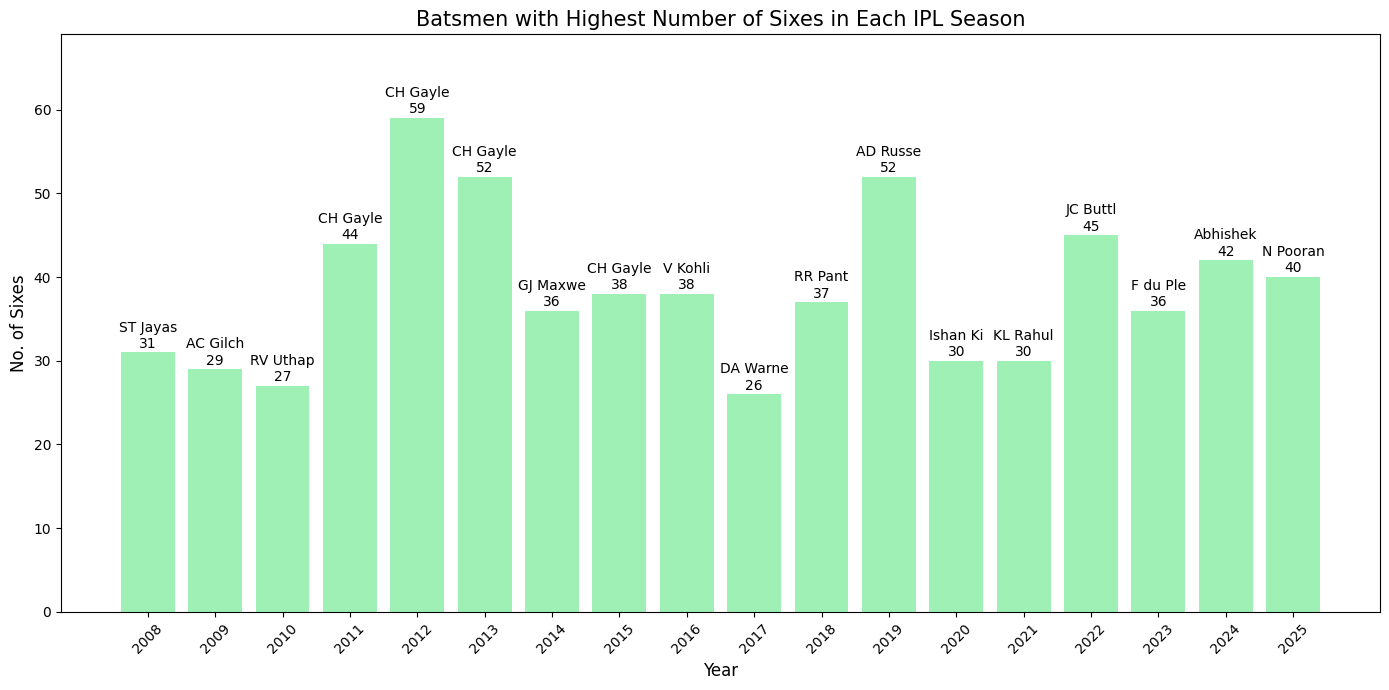

In [23]:
plt.figure(figsize=(14,7))
plt.bar(Highest_sixes['year'].astype(str), Highest_sixes['is_six'], color="#9ef0b4")
plt.xlabel('Year', fontsize=12)
plt.ylabel('No. of Sixes', fontsize=12)
plt.title('Batsmen with Highest Number of Sixes in Each IPL Season',fontsize=15)
for i, (batsman, is_six, year) in enumerate(zip(Highest_sixes['batsman'],
                                               Highest_sixes['is_six'],
                                               Highest_sixes['year'])):
  plt.text(i, is_six + 2, f"{batsman[:8]}\n{is_six}", ha='center', va='center', fontweight='500')

plt.ylim(0, Highest_sixes['is_six'].max() + 10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/Highest_sixes.png")
plt.show()

In [16]:
df.columns

Index(['inning', 'over_ball', 'over', 'ball', 'batting_team', 'bowling_team',
       'batsman', 'non_striker', 'bowler', 'batsman_runs', 'extras', 'isWide',
       'isNoBall', 'Byes', 'LegByes', 'Penalty', 'dismissal_kind',
       'player_dismissed', 'date', 'year', 'is_six'],
      dtype='str')